In [16]:
# Task 3 PRICE RANGE VS ONLINE DELIVERY & TABLE BOOKING
# analyze if there is a relationship between the price range & the availability of online delivery & table booking

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#load the dataset
df = pd.read_csv(r"C:\Users\Acer\Downloads\Dataset.csv")
df.shape

# Convert Yes/No to 1/0
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})
df['Has Table booking'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})

# Drop missing values
df = df.dropna(subset=['Price range', 'Has Online delivery', 'Has Table booking'])

# Grouped averages
print(df.groupby('Price range')[['Has Online delivery', 'Has Table booking']].mean())


             Has Online delivery  Has Table booking
Price range                                        
1                       0.157741           0.000225
2                       0.413106           0.076775
3                       0.291903           0.457386
4                       0.090444           0.467577


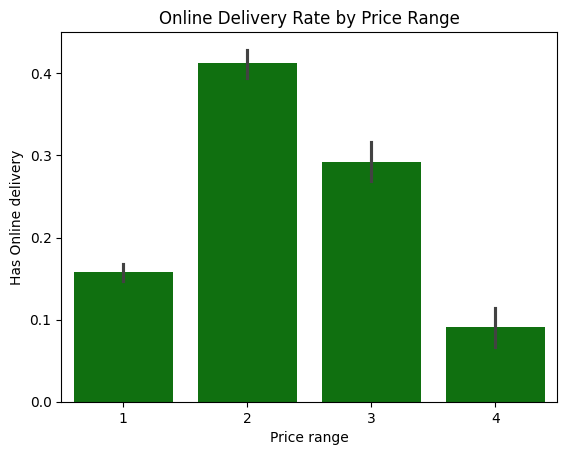

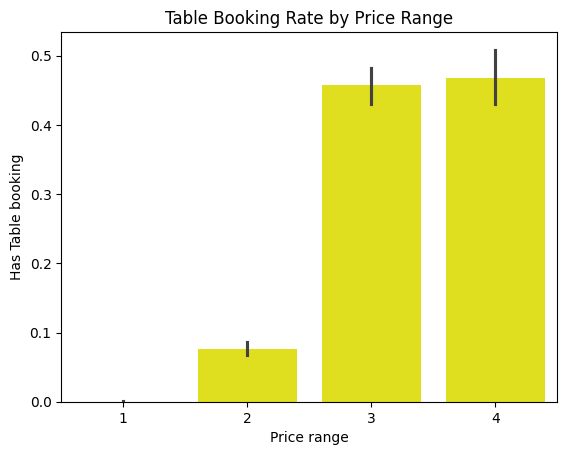

In [15]:
# Visualization
sns.barplot(data=df, x='Price range', y='Has Online delivery',color = 'green')
plt.title('Online Delivery Rate by Price Range')
plt.show()

sns.barplot(data=df, x='Price range', y='Has Table booking',color = 'yellow')
plt.title('Table Booking Rate by Price Range')
plt.show()

In [26]:
# Determine if higher-priced restaurants are more likely to offer these services.

# correlation (higher price range vs service availability)
print("\nCorrelations:")
print(df[['Price range', 'Has Online delivery', 'Has Table booking']].corr())


Correlations:
                     Price range  Has Online delivery  Has Table booking
Price range             1.000000             0.077918           0.501925
Has Online delivery     0.077918             1.000000           0.101224
Has Table booking       0.501925             0.101224           1.000000


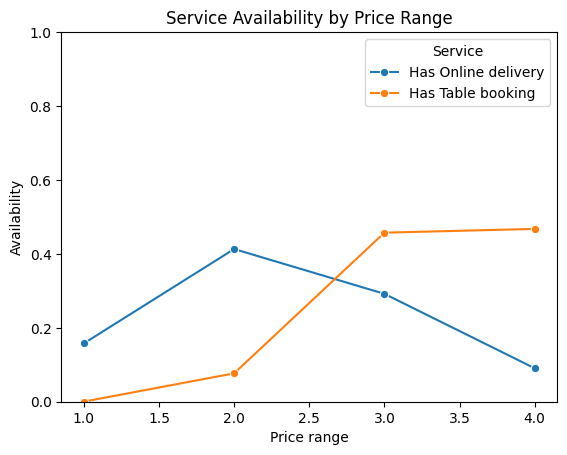

In [27]:
grouped = df.groupby('Price range')[['Has Online delivery', 'Has Table booking']].mean().reset_index()
melted = grouped.melt(id_vars='Price range', var_name='Service', value_name='Availability')

# plot trends
sns.lineplot(data=melted, x='Price range', y='Availability', hue='Service', marker='o')
plt.title('Service Availability by Price Range')
plt.ylim(0, 1)
plt.show()